# Crude: Which variables are the strongest predictors for supply and demand?

This notebook ranks individual predictors for next-month U.S. supply and demand. 

Supply and demand are separate targets.


In [1]:
FUEL = 'crude'
from pathlib import Path
import sys, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import sklearn
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_colwidth', 100)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'oil/us_snd_crude/crude_data.py').exists())
for fuel in ['crude', 'gasoline']:
    sys.path.insert(0, str(ROOT/f'oil/us_snd_{fuel}'))
from crude_data import load_panel as load_crude, FLOWS as CRUDE_FLOWS
from gasoline_data import load_panel as load_gasoline, FLOWS as GAS_FLOWS
panels = {'crude': load_crude(), 'gasoline': load_gasoline()}
national = {}
for fuel, panel in panels.items():
    assert panel.groupby('month').padd.nunique().eq(5).all()
    cols = (CRUDE_FLOWS + ['stock_kb', 'cdu_capacity_kbd']) if fuel == 'crude' else GAS_FLOWS + ['stock_kb']
    z = panel.groupby('month')[cols].sum(min_count=5).asfreq('MS')
    assert z.notna().all().all()
    # Every flow becomes thousand barrels/day; stocks become million barrels.
    if fuel == 'gasoline':
        for c in GAS_FLOWS:
            z[c.replace('_kb', '_kbd')] = z[c] / z.index.days_in_month
    z['stock_mb'] = z.stock_kb / 1000
    z['change_mb'] = z.stock_mb.diff()
    z['net_imports_kbd'] = z.imports_kbd - z.exports_kbd
    z['core_balance_kbd'] = z.production_kbd + z.net_imports_kbd - z.demand_kbd
    if fuel == 'crude':
        z['utilization'] = z.demand_kbd / z.cdu_capacity_kbd
    national[fuel] = z
manifest = []
for fuel in national:
    path = ROOT/f'oil/us_snd_{fuel}/data/eia_observations.csv'
    manifest.append({'fuel': fuel, 'start': national[fuel].index.min(), 'end': national[fuel].index.max(),
                     'months': len(national[fuel]), 'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})


## How variable importantce is measured

We test each variable separately while accounting for seasonal pattersn (which variables are most important other than season. Controlling for season). Variables that reduce prediction errors the most are the most important.

The test uses six historical periods, with each prediction based only on earlier data.

We  remove each variable from the model containing all inputs and refit to measure the information it adds alongside the other variables.

In [2]:
z = national[FUEL]
other_fuel = 'gasoline' if FUEL == 'crude' else 'crude'
other = national[other_fuel].reindex(z.index)
demand_name = 'Crude refinery inputs' if FUEL == 'crude' else 'Gasoline product supplied'
production_name = 'Crude production' if FUEL == 'crude' else 'Gasoline net production'
targets = pd.DataFrame({
    'Supply: production + imports': z.production_kbd + z.imports_kbd,
    'Demand: ' + demand_name.lower(): z.demand_kbd,
})
X = pd.DataFrame(index=z.index)
for month in range(1, 13):
    X[f'Calendar month {month:02}'] = (X.index.month == month).astype(float)
calendar = list(X.columns)

def history(name, series):
    X[f'{name} — previous month'] = series.shift(1)
    X[f'{name} — previous 3-month average'] = series.shift(1).rolling(3).mean()

history(production_name, z.production_kbd)
history(FUEL.title() + ' imports', z.imports_kbd)
history(FUEL.title() + ' exports', z.exports_kbd)
history(demand_name, z.demand_kbd)
history('Supply (production + imports)', targets.iloc[:, 0])
history('Core balance (production + imports − exports − demand)', z.core_balance_kbd)
X['Inventory level — previous month'] = z.stock_mb.shift(1)
X['Inventory change — previous month'] = z.change_mb.shift(1)
X['Inventory change — previous 3-month average'] = z.change_mb.shift(1).rolling(3).mean()
X['Inventory level minus year-earlier level'] = z.stock_mb.shift(1) - z.stock_mb.shift(13)
for column, name in [('adjustments_kbd', 'Adjustments'), ('net_receipts_kbd', 'Net regional receipts')]:
    history(name, z[column])
if FUEL == 'crude':
    history('Transfers', z.transfers_kbd)
    history('Direct crude use', z.direct_use_kbd)
else:
    history('Biofuel production', z.biofuels_kbd)
# Crude refinery operating data are potentially relevant to both products.
crude = national['crude'].reindex(z.index)
X['Crude refinery utilization — previous month'] = crude.utilization.shift(1)
X['Crude distillation capacity — previous month'] = crude.cdu_capacity_kbd.shift(1)
other_demand = 'Gasoline product supplied' if other_fuel == 'gasoline' else 'Crude refinery inputs'
other_production = 'Gasoline net production' if other_fuel == 'gasoline' else 'Crude production'
X[f'{other_demand} — previous month'] = other.demand_kbd.shift(1)
X[f'{other_production} — previous month'] = other.production_kbd.shift(1)
X[f'{other_fuel.title()} inventory change — previous month'] = other.change_mb.shift(1)

keep = X.notna().all(axis=1) & targets.notna().all(axis=1)
X, targets = X.loc[keep], targets.loc[keep]
# Exclude target months and their entire 13-month input history touching this disruption.
eligible = pd.Series(True, index=X.index)
for offset in range(14):
    dates = X.index - pd.DateOffset(months=offset)
    eligible &= ~((dates >= pd.Timestamp('2020-03-01')) & (dates <= pd.Timestamp('2021-03-01')))
scored_dates = X.index[eligible][-72:]
assert len(scored_dates) == 72
# Breaks around the excluded interval remain explicit in the period labels.
folds = [pd.DatetimeIndex(d) for d in np.array_split(scored_dates, 6)]
features = [c for c in X if c not in calendar]
assert X.index.is_monotonic_increasing and not X.index.has_duplicates
assert np.isfinite(X.to_numpy()).all() and np.isfinite(targets.to_numpy()).all()
assert len(features) == len(set(features))
periods = pd.DataFrame([{
    'Period': i + 1, 'First scored month': dates.min().strftime('%Y-%m'),
    'Last scored month': dates.max().strftime('%Y-%m'), 'Scored months': len(dates),
    'Earlier training months': int(((X.index < dates.min()) & eligible).sum()),
} for i, dates in enumerate(folds)])
assert periods['Earlier training months'].min() >= 36


In [3]:
# Fixed regularization avoids tuning each variable on the same periods used to rank it.
ALPHA = 10
def errors(y, columns):
    blocks = []
    for period, dates in enumerate(folds, 1):
        train = (X.index < dates.min()) & eligible
        assert X.index[train].max() < dates.min()
        model = make_pipeline(StandardScaler(), Ridge(alpha=ALPHA))
        model.fit(X.loc[train, columns], y.loc[train])
        prediction = model.predict(X.loc[dates, columns])
        blocks.append(pd.DataFrame({
            'period': period, 'error': np.abs(y.loc[dates].to_numpy() - prediction)
        }, index=dates))
    return pd.concat(blocks)

rankings, calendar_importance = {}, []
for target_name in targets:
    y = targets[target_name]
    calendar_error = errors(y, calendar)
    full_error = errors(y, list(X.columns))
    rows = []
    for feature in features:
        added = errors(y, calendar + [feature])
        removed = errors(y, [c for c in X if c != feature])
        gain = calendar_error.error - added.error
        conditional = removed.error - full_error.error
        by_period = gain.groupby(calendar_error.period).mean()
        rows.append({
            'Predictor': feature,
            'Error reduction vs calendar (thousand b/d)': gain.mean(),
            'Error reduction vs calendar (%)': 100 * gain.mean() / calendar_error.error.mean(),
            'Periods helped (of 6)': int((by_period > 0).sum()),
            'Error increase when removed (thousand b/d)': conditional.mean(),
            'Periods hurt by removal (of 6)': int((conditional.groupby(full_error.period).mean() > 0).sum()),
            **{f'Period {i} gain': by_period.loc[i] for i in range(1, 7)},
        })
    table = pd.DataFrame(rows).sort_values(
        'Error reduction vs calendar (thousand b/d)', ascending=False
    ).reset_index(drop=True)
    table.index = table.index + 1
    table.index.name = 'Rank'
    rankings[target_name] = table
    without_calendar = errors(y, features)
    calendar_importance.append({
        'Target': target_name,
        'Predictor': 'Calendar month (all 12 month indicators)',
        'Error increase when removed (thousand b/d)': (without_calendar.error - full_error.error).mean(),
    })


## Most important variables

The top three individual predictors for each target appear first.

In [4]:
gain_column = 'Error reduction vs calendar (thousand b/d)'
conditional_column = 'Error increase when removed (thousand b/d)'
summary = []
for target_name, table in rankings.items():
    positive = table[table[gain_column] > 0].head(3)
    for rank, row in positive.iterrows():
        summary.append({
            'Target': target_name, 'Rank': rank, 'Predictor': row.Predictor,
            'Error reduction (thousand b/d)': row[gain_column],
            'Periods helped (of 6)': row['Periods helped (of 6)'],
            'Adds information alongside other inputs': bool(row[conditional_column] > 0),
        })
    if positive.empty:
        display(Markdown(f'**{target_name}:** No individual predictor improves on calendar month in these tests.'))
display(pd.DataFrame(summary).round(2))

,Target,Rank,Predictor,Error reduction (thousand b/d),Periods helped (of 6),Adds information alongside other inputs
0,Supply: production + imports,1,Supply (production + imports) — previous 3-month average,2785.23,6,True
1,Supply: production + imports,2,Supply (production + imports) — previous month,2714.99,6,True
2,Supply: production + imports,3,Crude production — previous 3-month average,2689.13,6,True
3,Demand: crude refinery inputs,1,Crude refinery inputs — previous 3-month average,532.84,6,True
4,Demand: crude refinery inputs,2,Crude refinery inputs — previous month,518.87,6,True
5,Demand: crude refinery inputs,3,Gasoline net production — previous month,422.99,6,True


For crude supply, the previous three month average of production plus imports was most important.

For crude demand, the previous three month average of refinery inputs was most important.

## Individual predictor rankings

### Supply: production + imports

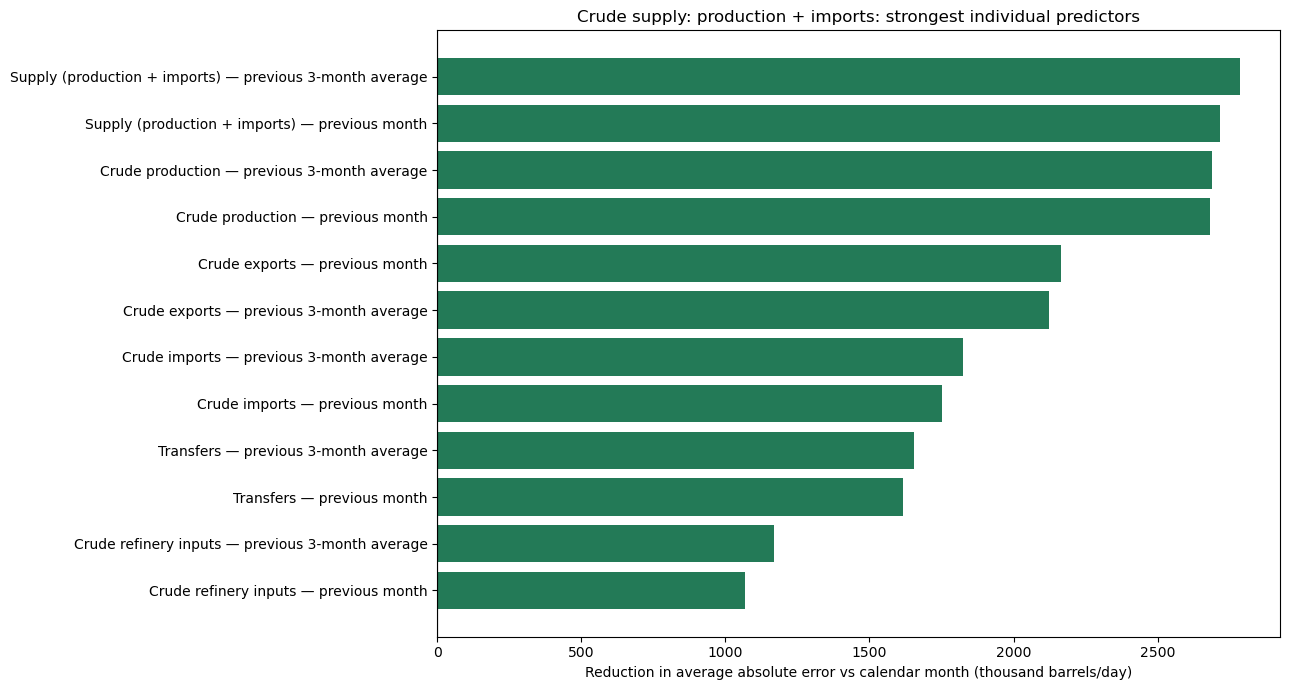

,Predictor,Error reduction vs calendar (thousand b/d),Error reduction vs calendar (%),Periods helped (of 6),Error increase when removed (thousand b/d),Periods hurt by removal (of 6)
Rank,,,,,,
1,Supply (production + imports) — previous 3-month average,2785.23,88.79,6,4.65,4
2,Supply (production + imports) — previous month,2714.99,86.55,6,1.17,3
3,Crude production — previous 3-month average,2689.13,85.72,6,0.41,2
4,Crude production — previous month,2680.78,85.46,6,0.51,5
5,Crude exports — previous month,2165.55,69.03,6,-16.66,1
6,Crude exports — previous 3-month average,2123.85,67.70,6,6.87,3
7,Crude imports — previous 3-month average,1824.12,58.15,6,-0.71,2
8,Crude imports — previous month,1750.54,55.80,6,-1.12,4
9,Transfers — previous 3-month average,1654.87,52.75,4,3.71,3


### Demand: crude refinery inputs

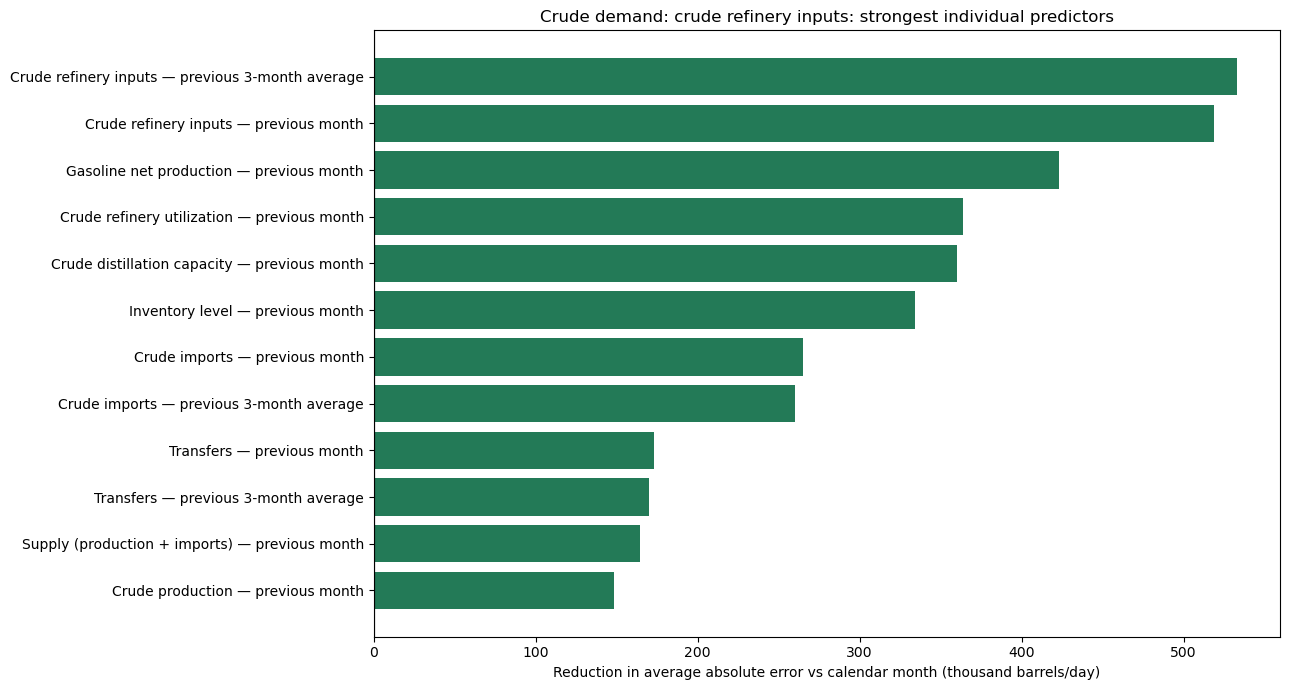

,Predictor,Error reduction vs calendar (thousand b/d),Error reduction vs calendar (%),Periods helped (of 6),Error increase when removed (thousand b/d),Periods hurt by removal (of 6)
Rank,,,,,,
1,Crude refinery inputs — previous 3-month average,532.84,67.46,6,8.34,4
2,Crude refinery inputs — previous month,518.87,65.69,6,5.96,6
3,Gasoline net production — previous month,422.99,53.55,6,3.23,4
4,Crude refinery utilization — previous month,363.68,46.04,6,0.89,4
5,Crude distillation capacity — previous month,359.87,45.56,6,7.58,4
6,Inventory level — previous month,334.02,42.29,6,12.87,1
7,Crude imports — previous month,265.04,33.55,5,-1.31,1
8,Crude imports — previous 3-month average,259.92,32.91,5,-2.33,2
9,Transfers — previous month,172.88,21.89,4,-7.27,4


In [5]:
for target_name, table in rankings.items():
    display(Markdown('### ' + target_name))
    top = table.head(12).iloc[::-1]
    fig, ax = plt.subplots(figsize=(13, 7))
    colors = ['#237a57' if value > 0 else '#b65a52' for value in top[gain_column]]
    ax.barh(top.Predictor, top[gain_column], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(FUEL.title() + ' ' + target_name.lower() + ': strongest individual predictors')
    ax.set_xlabel('Reduction in average absolute error vs calendar month (thousand barrels/day)')
    ax.set_ylabel('')
    fig.tight_layout()
    plt.show()
    display(table.drop(columns=[f'Period {i} gain' for i in range(1, 7)]).round(2))


The three-month average of supply reduces error by about 2,785 thousand barrels/day versus calendar month alone. 

For demand, the three-month average of refinery inputs reduces error by about 533 thousand barrels/day.

## Which variables matter alongside the others?

These rankings remove one input at a time from a ridge model. Positive values mean that removing the input makes predictions worse. Negative values mean predictions improve without it. 


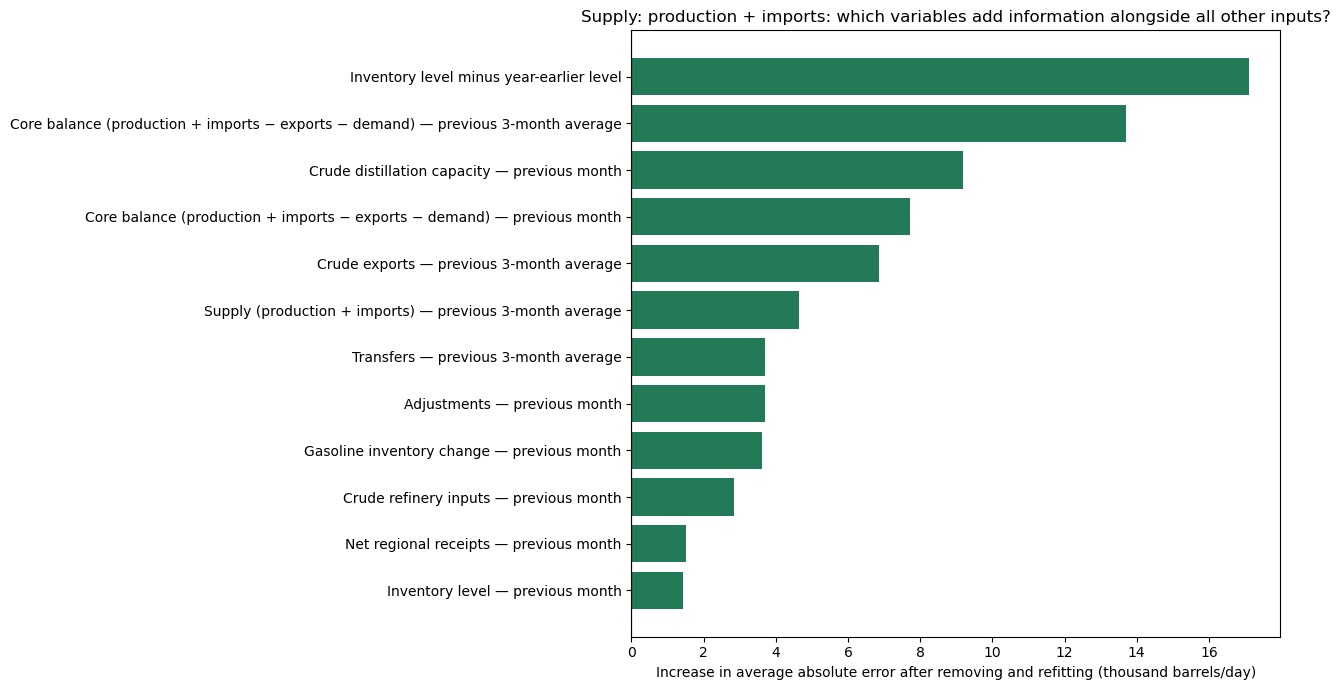

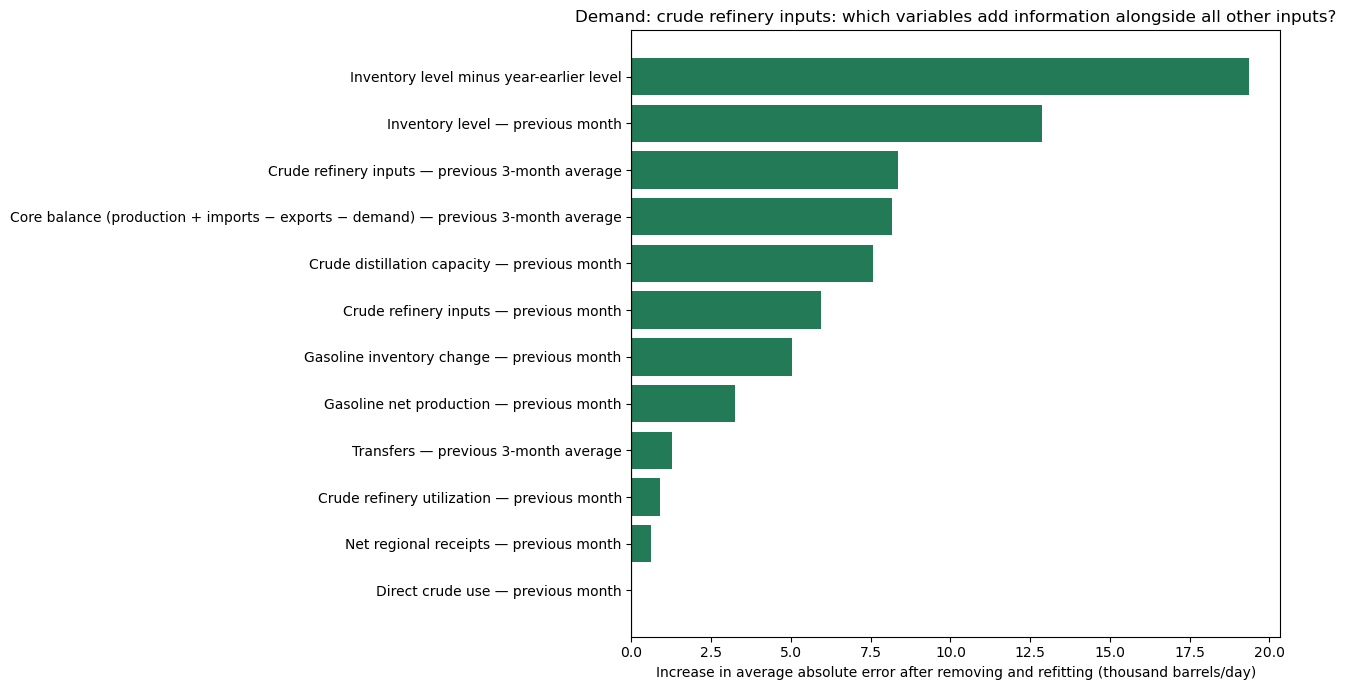

,Target,Predictor,Error increase when removed (thousand b/d)
0,Supply: production + imports,Calendar month (all 12 month indicators),10.96
1,Demand: crude refinery inputs,Calendar month (all 12 month indicators),70.65


In [6]:
for target_name, table in rankings.items():
    ordered = table.sort_values(conditional_column, ascending=False).head(12).iloc[::-1]
    fig, ax = plt.subplots(figsize=(13, 7))
    ax.barh(ordered.Predictor, ordered[conditional_column],
            color=['#237a57' if v > 0 else '#b65a52' for v in ordered[conditional_column]])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(target_name + ': which variables add information alongside all other inputs?')
    ax.set_xlabel('Increase in average absolute error after removing and refitting (thousand barrels/day)')
    fig.tight_layout()
    plt.show()
display(pd.DataFrame(calendar_importance).round(2))


The inventory level minus its year-earlier level adds the most information in the removal test for both supply and demand as removing it increases error by about 17 and 19 thousand barrels/day, respectively.

These variables are weak on their own as above they did not provide much error reduction but helps the model interpret the other inputs.

## How consistent is each predictor?

In [7]:
for target_name, table in rankings.items():
    display(Markdown('### ' + target_name))
    columns = [f'Period {i} gain' for i in range(1, 7)]
    display(table.head(10).set_index('Predictor')[columns].round(2))
display(periods)


### Supply: production + imports

,Period 1 gain,Period 2 gain,Period 3 gain,Period 4 gain,Period 5 gain,Period 6 gain
Predictor,,,,,,
Supply (production + imports) — previous 3-month average,2948.14,2770.35,2296.66,2963.14,2867.23,2865.89
Supply (production + imports) — previous month,2832.89,2658.28,2315.81,2824.48,2840.18,2818.30
Crude production — previous 3-month average,2259.66,2765.29,2447.02,2885.96,2886.88,2889.98
Crude production — previous month,2280.37,2775.27,2429.86,2850.80,2868.68,2879.71
Crude exports — previous month,2269.84,1646.04,947.51,2845.58,2801.79,2482.57
Crude exports — previous 3-month average,2013.54,1499.73,823.63,2899.20,2867.48,2639.53
Crude imports — previous 3-month average,639.94,1837.42,2196.10,1915.91,2045.95,2309.38
Crude imports — previous month,637.45,1731.04,2133.58,1763.34,2022.97,2214.84
Transfers — previous 3-month average,0.00,0.00,1787.08,2824.23,2847.98,2469.95


### Demand: crude refinery inputs

,Period 1 gain,Period 2 gain,Period 3 gain,Period 4 gain,Period 5 gain,Period 6 gain
Predictor,,,,,,
Crude refinery inputs — previous 3-month average,1180.18,723.90,100.87,162.37,435.21,594.49
Crude refinery inputs — previous month,1149.94,693.03,137.86,133.80,451.07,547.53
Gasoline net production — previous month,990.77,692.43,155.77,117.26,289.92,291.78
Crude refinery utilization — previous month,807.61,276.94,92.14,63.61,388.54,553.25
Crude distillation capacity — previous month,987.72,463.80,47.34,223.92,359.60,76.84
Inventory level — previous month,532.47,607.69,24.76,240.23,310.27,288.70
Crude imports — previous month,450.37,509.41,-473.32,55.88,403.96,643.96
Crude imports — previous 3-month average,487.37,505.49,-583.87,63.74,458.07,628.70
Transfers — previous month,0.00,0.00,119.15,195.06,345.31,377.76


,Period,First scored month,Last scored month,Scored months,Earlier training months
0,1,2018-05,2019-04,12,123
1,2,2019-05,2022-06,12,135
2,3,2022-07,2023-06,12,147
3,4,2023-07,2024-06,12,159
4,5,2024-07,2025-06,12,171
5,6,2025-07,2026-06,12,183


Recent supply, crude production, exports and imports help predict supply in all six periods when tested individually.

For demand, recent refinery inputs, gasoline net production, refinery utilization and distillation capacity also help in all six periods.

The additional value of a variable is less uniform once all inputs are present. For example, the year-over-year inventory difference helps the full supply model in five periods, but the full demand model in only three.

## Conclusion

For crude supply, recent production and supply levels are the strongest individual predictors. For crude demand, recent refinery inputs are strongest, with gasoline production and refinery operating measures as other strong predictors. The three-month averages of supply and refinery inputs are stronger than their previous-month values.

Inventory information is generally less important on its own, but the year-over-year inventory difference adds information alongside the other variables. (This is kind of a proxy for seasonality)

## Comparing crude and gasoline

Gasoline is easier to predict compared to crude based on these tests as its errors are smaller both in barrels/day and relative to the size of supply or demand.

The strongest predictors are similar, but the variables that add information alongside the other inputs differ.

Table below shows average absolute error by the average target level to account for crude volumes being larger than gasoline volumes.

| Target | Full-model error, thousand barrels/day | Error as % of average target | Best individual predictor + calendar: error % |
|---|---:|---:|---:|
| Crude supply | 354 | 1.82% | 1.81% |
| Gasoline supply | 138 | 1.40% | 1.63% |
| Crude demand | 338 | 2.07% | 1.57% |
| Gasoline demand | 110 | 1.22% | 1.20% |

Gasoline has lower relative errors for both targets, even when using just the strongest individual predictor plus calendar effects.

However, crude improves more relative to the baseline of only using the month of the year. Its full model reduces supply error by 89%, compared with 60% for gasoline. For demand, the reductions are 57% and 46%. This means crude has larger error reductions.

### Do the important predictors differ?

The strongest individual predictor are the same.

| Target | Crude | Gasoline |
|---|---|---|
| Supply | Previous three-month average of production + imports | Previous three-month average of production + imports |
| Demand | Previous three-month average of refinery inputs | Previous three-month average of product supplied |

Second most important predictors were:

- **Crude supply:** recent crude production 
- **Crude demand:** gasoline production

- **Gasoline supply:** crude distillation capacity
- **Gasoline demand:** recent product supplied


| Target | Largest error increase when a variable is removed |
|---|---|
| Crude supply | Crude year-over-year inventory difference: **17.1 thousand b/d** |
| Crude demand | Crude year-over-year inventory difference: **19.4 thousand b/d** |
| Gasoline supply | Previous-month crude inventory change: **7.6 thousand b/d** |
| Gasoline demand | Three-month average gasoline product supplied: **9.2 thousand b/d** |

Previous-month crude inventory change also helps the full gasoline demand model: removing it increases error by 6.0 thousand b/d.